<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_7_(Exercise_7_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Imports and Data

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from skimage.metrics import structural_similarity as ssim_fn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Images in [0,1] — needed for VGG normalisation later
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(root='./data', train=True,
                              download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=64,
                          shuffle=True, num_workers=0)

test_data = datasets.CIFAR10(root='./data', train=False,
                             download=True, transform=transform)
test_data = Subset(test_data, range(500))
test_loader = DataLoader(test_data, batch_size=64,
                         shuffle=False, num_workers=0)

Using: cpu


100%|██████████| 170M/170M [47:03<00:00, 60.4kB/s]


In [ ]:
 # Install LPIPS (official implementation)

!pip install lpips -q
import lpips

lpips_fn = lpips.LPIPS(net='alex').to(device)   # standard choice in the LPIPS paper
for p in lpips_fn.parameters():
    p.requires_grad_(False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 142MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [ ]:
# Autoencoder Architecture (identical for both models)

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 32→16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16→8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8→4
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_enc = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 4→8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 8→16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),    # 16→32
            nn.Sigmoid()    # output in [0,1] to match input range
        )

    def forward(self, x):
        z = self.fc_enc(self.encoder(x))
        out = self.decoder(self.fc_dec(z))
        return out

In [ ]:
# Frozen VGG-16 Feature Extractor at relu2_2 and relu3_3

class VGGPerceptual(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.slice1 = nn.Sequential(*list(vgg.children())[:9])    # up to relu2_2 (idx 8)
        self.slice2 = nn.Sequential(*list(vgg.children())[9:16])  # relu2_2 → relu3_3 (idx 15)

        for p in self.parameters():
            p.requires_grad_(False)
        self.eval()

        # ImageNet normalisation — VGG expects this
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        f1 = self.slice1(x)          # relu2_2 features
        f2 = self.slice2(f1)         # relu3_3 features
        return f1, f2


vgg_extractor = VGGPerceptual().to(device)


def perceptual_loss(x, x_hat, vgg_extractor):
    f1_x,  f2_x  = vgg_extractor(x)
    f1_xh, f2_xh = vgg_extractor(x_hat)
    loss_relu2_2 = F.l1_loss(f1_x, f1_xh)
    loss_relu3_3 = F.l1_loss(f2_x, f2_xh)
    return loss_relu2_2 + loss_relu3_3

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 115MB/s]


In [5]:
# Train Both Models, Identical Hyperparameters

def train_autoencoder(use_perceptual, epochs=12, lam_percep=0.1):
    model     = Autoencoder(latent_dim=128).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)

            recon = model(imgs)
            l1_loss = F.l1_loss(recon, imgs)

            if use_perceptual:
                p_loss = perceptual_loss(imgs, recon, vgg_extractor)
                loss = l1_loss + lam_percep * p_loss
            else:
                loss = l1_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"[{'L1+percep' if use_perceptual else 'L1 only'}] "
              f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}")

    return model


print("Training Model A — L1 pixel loss only...")
model_l1 = train_autoencoder(use_perceptual=False, epochs=12)

print("\nTraining Model B — L1 + perceptual loss...")
model_percep = train_autoencoder(use_perceptual=True, epochs=12)

Training Model A — L1 pixel loss only...
[L1 only] Epoch 1/12 — Loss: 0.1481
[L1 only] Epoch 2/12 — Loss: 0.0988
[L1 only] Epoch 3/12 — Loss: 0.0847
[L1 only] Epoch 4/12 — Loss: 0.0781
[L1 only] Epoch 5/12 — Loss: 0.0742
[L1 only] Epoch 6/12 — Loss: 0.0705
[L1 only] Epoch 7/12 — Loss: 0.0672
[L1 only] Epoch 8/12 — Loss: 0.0646
[L1 only] Epoch 9/12 — Loss: 0.0630
[L1 only] Epoch 10/12 — Loss: 0.0610
[L1 only] Epoch 11/12 — Loss: 0.0594
[L1 only] Epoch 12/12 — Loss: 0.0585

Training Model B — L1 + perceptual loss...
[L1+percep] Epoch 1/12 — Loss: 0.5253
[L1+percep] Epoch 2/12 — Loss: 0.4532
[L1+percep] Epoch 3/12 — Loss: 0.4191
[L1+percep] Epoch 4/12 — Loss: 0.4001
[L1+percep] Epoch 5/12 — Loss: 0.3872
[L1+percep] Epoch 6/12 — Loss: 0.3764
[L1+percep] Epoch 7/12 — Loss: 0.3670
[L1+percep] Epoch 8/12 — Loss: 0.3584
[L1+percep] Epoch 9/12 — Loss: 0.3513
[L1+percep] Epoch 10/12 — Loss: 0.3453
[L1+percep] Epoch 11/12 — Loss: 0.3405
[L1+percep] Epoch 12/12 — Loss: 0.3352


In [6]:
# Compute SSIM and LPIPS on the Test Set

def evaluate_model(model, loader, lpips_fn):
    model.eval()
    ssim_scores, lpips_scores = [], []

    with torch.no_grad():
        for imgs, _ in loader:
            imgs  = imgs.to(device)
            recon = model(imgs)

            # LPIPS expects [-1, 1] range
            lp = lpips_fn(imgs * 2 - 1, recon * 2 - 1)
            lpips_scores.extend(lp.squeeze().cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                orig = imgs[i].permute(1, 2, 0).cpu().numpy()
                rec  = recon[i].permute(1, 2, 0).cpu().numpy()
                s = ssim_fn(orig, rec, data_range=1.0, channel_axis=2)
                ssim_scores.append(s)

    return np.mean(ssim_scores), np.mean(lpips_scores)


ssim_l1, lpips_l1         = evaluate_model(model_l1, test_loader, lpips_fn)
ssim_percep, lpips_percep = evaluate_model(model_percep, test_loader, lpips_fn)

print(f"{'Model':<15} {'SSIM':>10} {'LPIPS':>10}")
print("-" * 36)
print(f"{'L1 only':<15} {ssim_l1:>10.4f} {lpips_l1:>10.4f}")
print(f"{'L1+percep':<15} {ssim_percep:>10.4f} {lpips_percep:>10.4f}")

Model                 SSIM      LPIPS
------------------------------------
L1 only             0.7085     0.1683
L1+percep           0.6939     0.1165


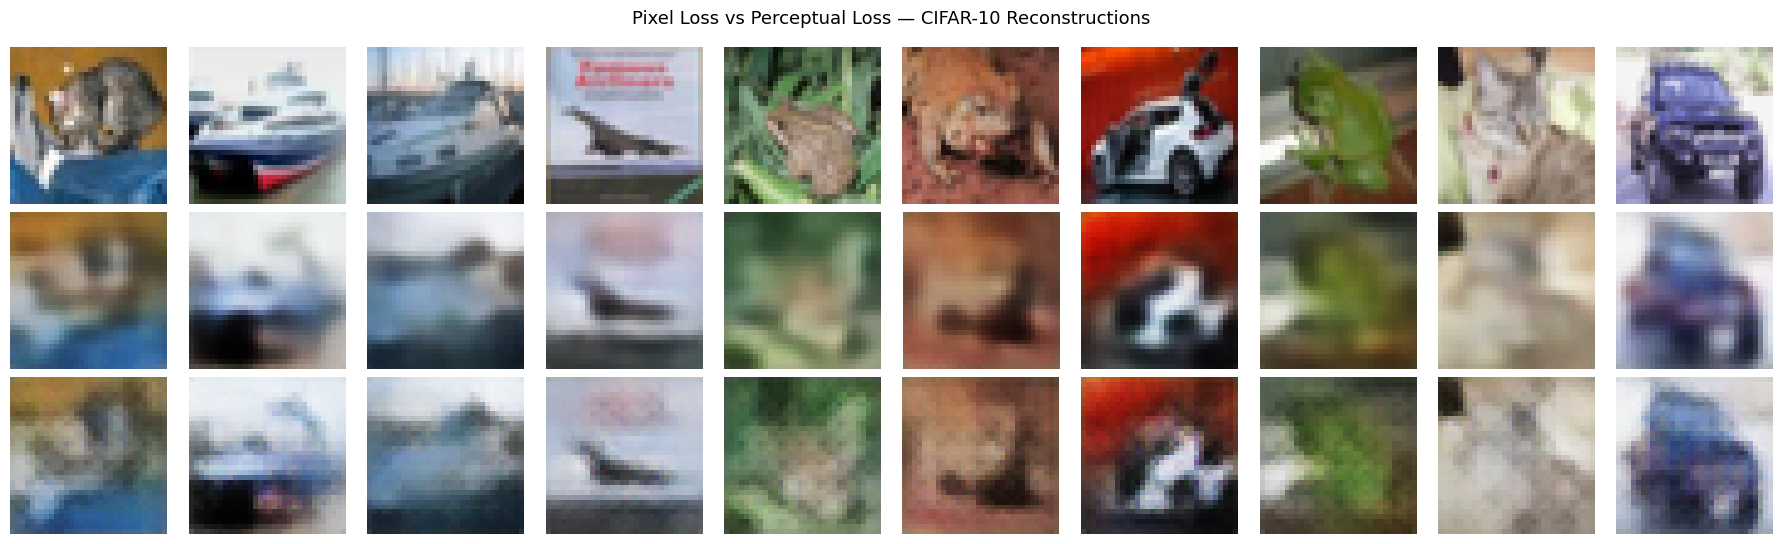

In [7]:
# Qualitative Grid: 10 Random Reconstructions

torch.manual_seed(7)
sample_imgs, _ = next(iter(test_loader))
sample_imgs    = sample_imgs[:10].to(device)

model_l1.eval()
model_percep.eval()
with torch.no_grad():
    recon_l1     = model_l1(sample_imgs)
    recon_percep = model_percep(sample_imgs)

fig, axes = plt.subplots(3, 10, figsize=(18, 5.5))
row_labels = ['Original', 'L1 only', 'L1 + perceptual']

for col in range(10):
    axes[0, col].imshow(sample_imgs[col].permute(1, 2, 0).cpu().numpy())
    axes[1, col].imshow(recon_l1[col].permute(1, 2, 0).cpu().numpy())
    axes[2, col].imshow(recon_percep[col].permute(1, 2, 0).cpu().numpy())
    for row in range(3):
        axes[row, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10)

plt.suptitle('Pixel Loss vs Perceptual Loss — CIFAR-10 Reconstructions', fontsize=13)
plt.tight_layout()
plt.savefig('perceptual_vs_pixel_7_1.png', dpi=150)
plt.show()

# Interpretation And Observation

#### Adding perceptual loss produced a small but real drop in SSIM, from 0.7085 to 0.6939, while LPIPS improved substantially, from 0.1683 to 0.1165. This is not two metrics disagreeing by chance — it is the expected signature of the proven perception-distortion tradeoff (Blau & Michaeli, 2018), which shows mathematically that distortion measures like SSIM and perceptual quality are fundamentally at odds for any restoration algorithm, regardless of which specific distortion metric is used. Pushing the reconstruction closer to the original in deep VGG feature space, which is what the perceptual loss term directly optimizes, provably comes at some cost to pixel-level structural similarity, so the direction of movement in both metrics is consistent with theory even though the absolute SSIM gap is small at this scale and training budget. The qualitative grid, however, reveals a confound that complicates a clean read of "perceptual loss equals sharper images" — the L1+perceptual row shows a visible checkerboard mesh pattern layered over still-blurry color blobs, rather than the crisper genuine texture the theory predicts. This pattern is a documented artifact of transposed convolutions (Odena, Dumoulin & Olah, 2016), caused by uneven kernel overlap during upsampling, and it specifically manifests here because perceptual loss actively pressures the decoder to inject high-frequency content to match VGG's texture-sensitive activations, while L1 loss alone never creates that pressure and so never triggers the architecture's latent tendency toward this artifact. With only 12 epochs on a 10k-image subset and a small decoder, the network had neither the capacity nor the training time to satisfy that pressure with genuine structured texture, so it fell into the cheaper checkerboard solution instead. This also explains why LPIPS still registered improvement despite the visible artifact: LPIPS itself is computed from deep network features, and any injection of high-frequency content, whether genuine texture or checkerboard noise, tends to register as a similar departure from blur in that feature space. The practical lesson carries directly into why LDAE's actual AutoencoderKL training does not rely on perceptual loss alone — it pairs perceptual loss with a patch-based adversarial objective specifically because a discriminator is well suited to catching exactly this kind of structured but unnatural artifact that a feature-distance loss can be fooled by, which is precisely what Exercise 7.2 builds next.